# Lab 6: Sparse Reconstruction with SIFT Features

In this lab, you'll learn how to extract and match **sparse features** from a stereo image pair and reconstruct a sparse 3D point cloud. Unlike dense reconstruction (Lab 5), which computes depth for every pixel using block matching, sparse reconstruction identifies distinctive keypoints in the images and matches them between views.

The workflow consists of:
1. **Feature Detection**: Finding salient points (corners, edges) in each image
2. **Feature Description**: Computing descriptors that characterize each keypoint's local appearance
3. **Feature Matching**: Finding correspondences between keypoints in the two images
4. **3D Reconstruction**: Triangulating matched points to recover their 3D positions

We'll use the **SIFT (Scale-Invariant Feature Transform)** algorithm, which is robust to changes in scale, rotation, and illumination. The key advantage of sparse reconstruction is computational efficiency and the ability to work with non-rectified images (though rectified images simplify the process).

## Background

### SIFT Feature Detection and Description

**SIFT (Scale-Invariant Feature Transform)** is a computer vision algorithm for detecting and describing local features in images. Developed by David Lowe (2004), SIFT is invariant to image scaling, rotation, and partially invariant to changes in illumination and 3D viewpoint ([Wikipedia - SIFT](https://en.wikipedia.org/wiki/Scale-invariant_feature_transform)).

The algorithm operates in several stages:
1. **Scale-space extrema detection**: Identifies potential keypoints by searching for local maxima/minima across different scales using Difference-of-Gaussian (DoG) filters
2. **Keypoint localization**: Refines keypoint positions and filters out low-contrast points and edge responses
3. **Orientation assignment**: Assigns dominant orientations to each keypoint based on local gradient directions, providing rotation invariance
4. **Descriptor generation**: Creates a 128-dimensional feature vector describing the local image gradients around each keypoint

In OpenCV, SIFT is implemented through `cv2.SIFT_create()`, which returns a detector object. The main methods are:
- `detectAndCompute(image, mask)`: Detects keypoints and computes their descriptors
- The returned keypoints are `cv2.KeyPoint` objects containing position, scale, and orientation
- Descriptors are 128-dimensional float vectors

### Feature Matching

After extracting features from both images, we need to find correspondences. OpenCV provides several matching strategies:

**BFMatcher (Brute Force Matcher)**: 
- `cv2.BFMatcher(normType, crossCheck)`: Compares each descriptor in the first set against all descriptors in the second set
- Common norm types: `cv2.NORM_L2` for SIFT/SURF, `cv2.NORM_HAMMING` for binary descriptors (ORB, BRIEF)
- `crossCheck=True` ensures that matches are mutual (A→B and B→A)

**FLANN (Fast Library for Approximate Nearest Neighbors)**:
- `cv2.FlannBasedMatcher(indexParams, searchParams)`: Faster but approximate matching
- Suitable for large datasets
- Requires appropriate index parameters for the descriptor type

Match quality can be improved using **Lowe's ratio test**: Accept a match only if the distance to the nearest neighbor is significantly smaller than the distance to the second-nearest neighbor (typical ratio: 0.7-0.8).

### 3D Reconstruction from Matched Features

Once we have correspondences between image points, we can recover their 3D positions. For a calibrated stereo system with known camera matrices $K$ and relative pose (rotation $R$, translation $t$), the reconstruction follows these steps:

1. **Triangulation**: Given corresponding points $(u_L, v_L)$ in the left image and $(u_R, v_R)$ in the right image, compute the 3D point $P$ that projects onto both image points. This is typically done using the Direct Linear Transform (DLT) method or similar techniques.

2. **Coordinate transformation**: The triangulated points are initially in the left camera's coordinate frame. They can be transformed to world coordinates using the known camera pose.

For rectified stereo images (where epipolar lines are horizontal), the math simplifies considerably:
- Disparity: $d = u_L - u_R$
- Depth: $Z = \frac{f \cdot B}{d}$
- 3D position: 
$$X = \frac{(u_L - c_x) \cdot Z}{f}, \quad Y = \frac{(v_L - c_y) \cdot Z}{f}, \quad Z = \frac{f \cdot B}{d}$$

where $f$ is focal length, $B$ is baseline, and $(c_x, c_y)$ is the principal point.

### Visualization and Analysis

The `vSet` class (in MATLAB's Computer Vision Toolbox) manages camera poses and views in a 3D reconstruction pipeline. For Python, we'll use custom classes or simple data structures to track:
- Camera poses (rotation and translation matrices)
- Feature point locations in each view
- Connections between views (matched features)

We'll use `pytransform3d` for coordinate frame visualization and transformations, and `matplotlib` or `plotly` for displaying the 3D point cloud with camera positions.

In [ ]:
%matplotlib inline
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import seaborn as sns
import matplotlib.pyplot as plt

# Configure plotting
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.labelsize": 11,
        "axes.titlesize": 12,
    }
)


In [ ]:
# Data directory configuration
ROOT_DIR = (Path.cwd().parent).resolve()
assert ROOT_DIR.exists(), f"Root directory does not exist: {ROOT_DIR}"
LV6_DIR = ROOT_DIR / ".data/LV_6"

# List available images
list(LV6_DIR.glob("*.jpg"))


[PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_5/scene_l.jpg'),
 PosixPath('/Users/jd/Desktop/repos/mobile-mapping/.data/LV_5/scene_r.jpg')]

## 1. Load and Visualize the Stereo Images

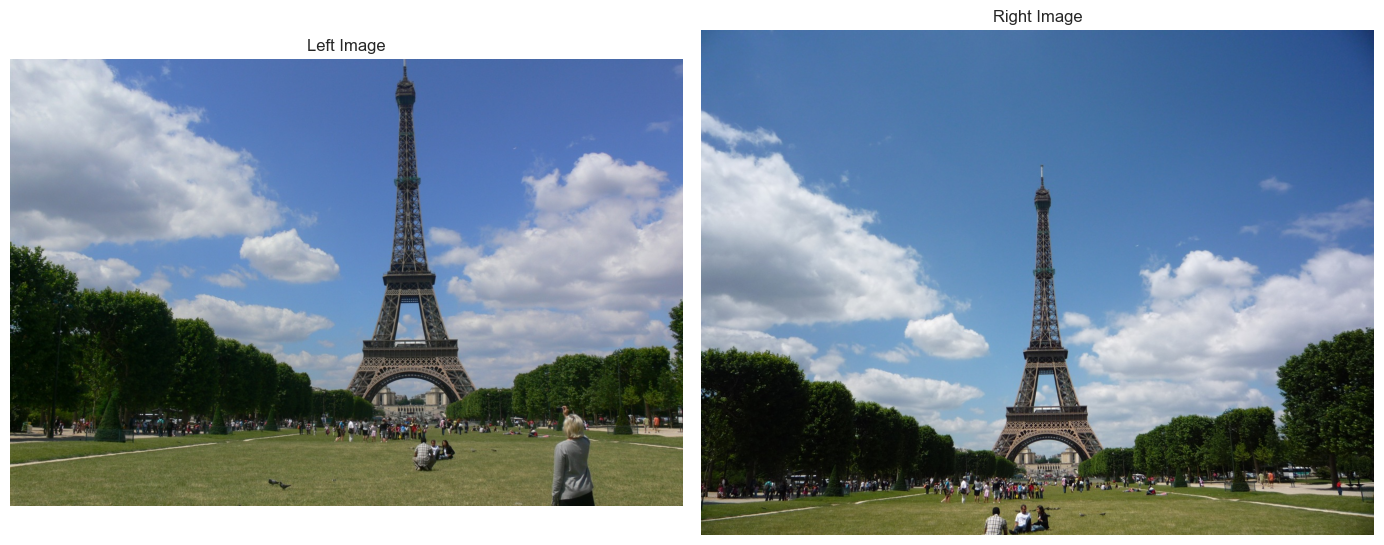

Image dimensions: (851, 1280)


In [5]:
# Load the stereo image pair
left_img_path = LV6_DIR / "eiffel2-1.jpg"
right_img_path = LV6_DIR / "eiffel2-2.jpg"

# Read images in color
left_color = cv2.imread(str(left_img_path))
right_color = cv2.imread(str(right_img_path))

# Convert to grayscale for feature detection
left_gray = cv2.cvtColor(left_color, cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right_color, cv2.COLOR_BGR2GRAY)

# Display the stereo pair
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 6))
ax0.imshow(cv2.cvtColor(left_color, cv2.COLOR_BGR2RGB))
ax0.set_title("Left Image")
ax0.axis("off")
ax1.imshow(cv2.cvtColor(right_color, cv2.COLOR_BGR2RGB))
ax1.set_title("Right Image")
ax1.axis("off")
plt.tight_layout()
plt.show()

print(f"Image dimensions: {left_gray.shape}")


## 2. Detect and Plot Harris Features

- [OpenCV :: cv2.cornerHarris](https://docs.opencv.org/3.4/dc/d0d/tutorial_py_features_harris.html)


### Why Dilation after Harris Corner Detection?

Dilation is a gray-scale morphological max filter. For an image $R(x,y)$ (here: the Harris response), dilation with a small structuring element replaces each pixel by the maximum in its neighborhood. Corners are local maxima $f$; dilation therefore^:
1. Thickens peaks for visualization. The true maxima are often single pixels. After dilation, a small area around each peak is pushed up toward the peak value, so the subsequent threshold (`dst > 0.01*dst.max()`) paints a blob instead of a barely visible dot. That’s why the tutorial comment says “for marking the corners.”
2. Makes connected components more stable (when you take centroids). In the sub-pixel example they run connectedComponentsWithStats on a thresholded map; dilation helps turn a speckled peak into one coherent blob, so the centroid is well-defined before cornerSubPix.

Structuring Element (Cross):
[[0 1 0]
 [1 1 1]
 [0 1 0]]


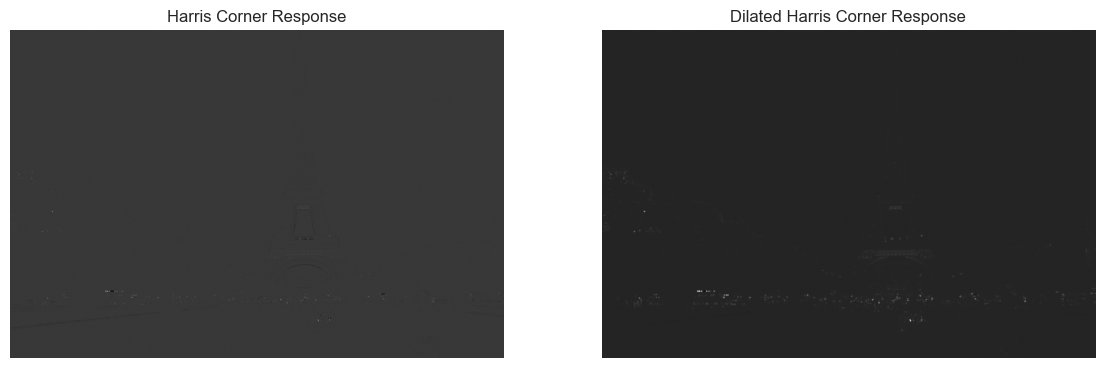

In [15]:
# Relative threshold for corner detection; only consider features above this fraction of the max response
REL_TRESH = 0.01
morph_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))

# Parameters:
# - src: input image (must be grayscale, float32)
# - blockSize: size of neighborhood (typically 2-5)
# - ksize: aperture parameter for Sobel operator (typically 3-31, must be odd)
# - k: Harris detector free parameter (typically 0.04-0.06)
harris_features = cv2.cornerHarris(left_gray, blockSize=2, ksize=3, k=0.04)

print("Structuring Element (Cross):")
print(morph_cross)
harris_features_dil = cv2.dilate(
    harris_features, kernel=morph_cross, borderType=cv2.BORDER_CONSTANT
)  # Dilate to mark the corners

# Plot the Harris features next to each other
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 6))

ax0.imshow(harris_features, cmap="gray")
ax0.set_title("Harris Corner Response")
ax0.axis("off")
ax1.imshow(harris_features_dil, cmap="gray")
ax1.set_title("Dilated Harris Corner Response")
ax1.axis("off")

plt.show()


In [53]:
threshold = REL_TRESH * harris_features.max()
corner_mask = harris_features > threshold

# Get corner coordinates
corner_coords = np.argwhere(corner_mask)
corners = np.column_stack((corner_coords[:, 0], corner_coords[:, 1]))
print(f"Number of corners detected: {len(corners)}")

# Get corner response values
corner_responses = harris_features[corner_mask]

# Sort by descending response strength
sorted_indices = np.argsort(corner_responses)[::-1]
corners = corners[sorted_indices]
corner_responses = corner_responses[sorted_indices]

# Combine response with coordinates
harris_keypoints = np.hstack((corners, corner_responses.reshape(-1, 1)))
print(f"Harris Keypoints.shape: {harris_keypoints.shape}")
print("Top 10 Harris Keypoints (y, x, response):")
print(harris_keypoints[:10])


Number of corners detected: 5918
Harris Keypoints.shape: (5918, 3)
Top 10 Harris Keypoints (y, x, response):
[[6.77000000e+02 2.53000000e+02 2.61130743e-02]
 [6.77000000e+02 2.58000000e+02 2.59077717e-02]
 [7.54000000e+02 7.99000000e+02 2.36856677e-02]
 [6.87000000e+02 3.26000000e+02 2.34314799e-02]
 [6.77000000e+02 2.48000000e+02 2.29694843e-02]
 [6.77000000e+02 2.71000000e+02 2.28557996e-02]
 [6.77000000e+02 2.52000000e+02 2.08741780e-02]
 [7.51000000e+02 7.98000000e+02 1.94454230e-02]
 [7.52000000e+02 7.98000000e+02 1.85499340e-02]
 [6.77000000e+02 2.51000000e+02 1.64241008e-02]]


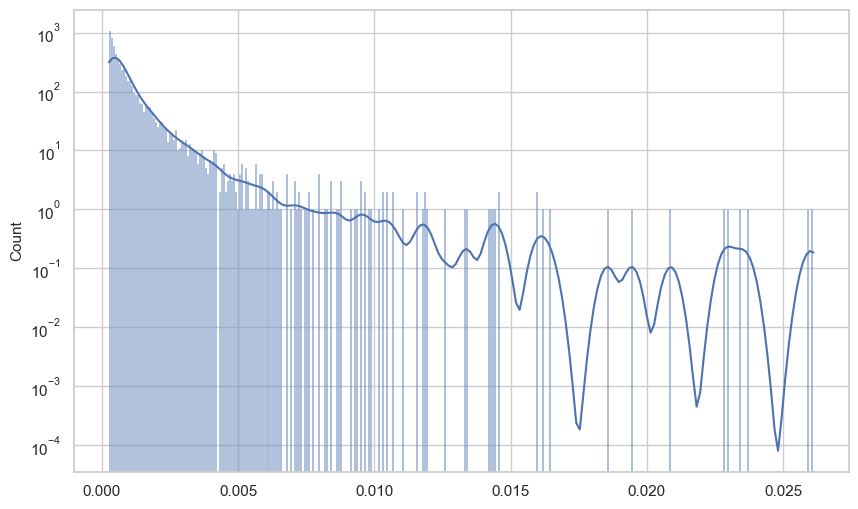

In [ ]:
# Plot histogram of Harris response values

sns.histplot(harris_keypoints[:, 2], kde=True)
plt.yscale("log")


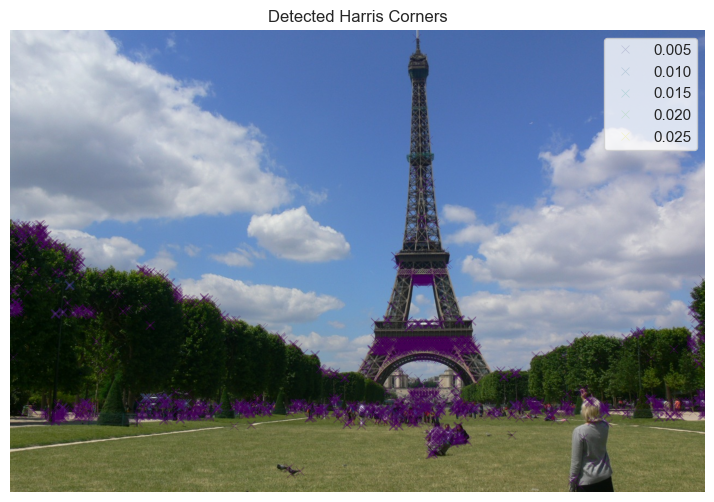

In [44]:
# Plot detected corners on the original image
plt.figure()
plt.imshow(cv2.cvtColor(left_color, cv2.COLOR_BGR2RGB))
sns.scatterplot(
    x=harris_keypoints[:, 1],
    y=harris_keypoints[:, 0],
    hue=harris_keypoints[:, 2],
    color="red",
    marker="x",
    # label="Harris Corners",
    palette="viridis",
    alpha=0.2,
)
plt.title("Detected Harris Corners")
plt.axis("off")
plt.show()


Number of corners after NMS: 268


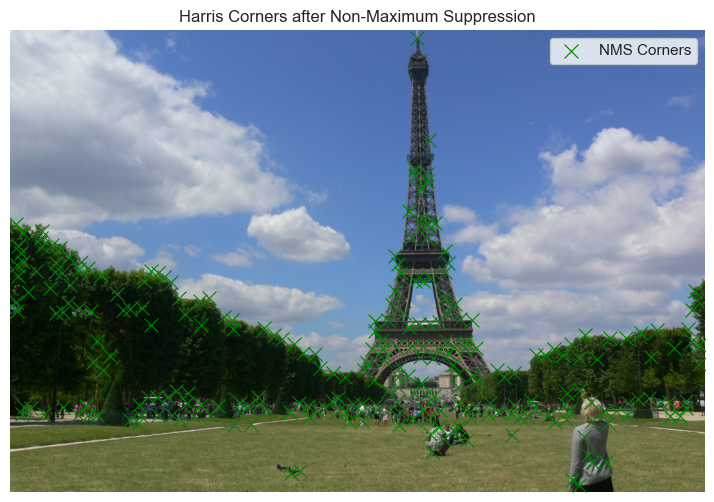

NMS Corner Coordinates (y, x):
[[ 676  253]
 [ 753  799]
 [ 686  326]
 [ 676  271]
 [ 702 1096]]


In [ ]:
# Apply non-maximum suppression (minimum distance constraint)
from skimage.feature import peak_local_max

nms_coords = peak_local_max(
    harris_features_dil,
    min_distance=10,  # Minimum distance between corners
    threshold_abs=REL_TRESH * harris_features_dil.max(),  # Absolute threshold
)

print(f"Number of corners after NMS: {len(nms_coords)}")
# Plot NMS corners on the original image

plt.figure()
plt.imshow(cv2.cvtColor(left_color, cv2.COLOR_BGR2RGB))
sns.scatterplot(
    x=nms_coords[:, 1],
    y=nms_coords[:, 0],
    marker="x",
    label="NMS Corners",
    color="green",
    s=100,
)
plt.title("Harris Corners after Non-Maximum Suppression")
plt.axis("off")
plt.legend()
plt.show()

print(f"NMS Corner Coordinates (y, x):\n{nms_coords[:5]}")


## 2. Detect SIFT Features

Use OpenCV's SIFT implementation to detect keypoints and compute descriptors for both images.

### Key OpenCV Functions:

- **`cv2.SIFT_create()`**: Creates a SIFT detector object
  - Optional parameters: `nfeatures` (maximum number of features), `contrastThreshold` (filter low-contrast keypoints), `edgeThreshold` (filter edge-like features)
  
- **`sift.detectAndCompute(image, mask=None)`**: Detects keypoints and computes descriptors
  - Returns: `keypoints` (list of cv2.KeyPoint objects), `descriptors` (Nx128 array)
  - Each KeyPoint has attributes: `pt` (x,y coordinates), `size` (scale), `angle` (orientation), `response` (strength)

For this task, we'll detect features in both images and visualize them. To limit the number of features and focus on the strongest ones, we can set a maximum number (e.g., 200) using the `nfeatures` parameter.

#keypoints_left 200, #keypoints_right 200
Descriptor shape (left): (200, 128)
Descriptor shape (right): (200, 128)


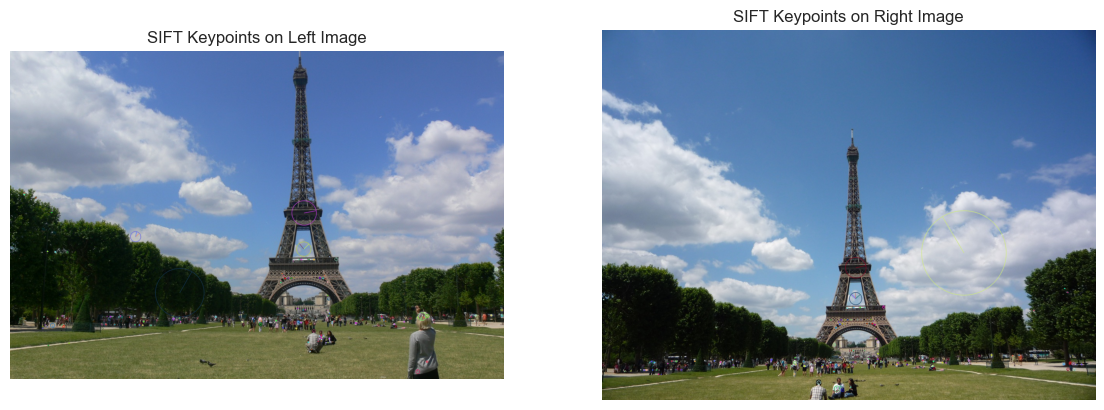

In [107]:
# Create a SIFT detector with a maximum of 200 features
sift = cv2.SIFT_create(nfeatures=None, nOctaveLayers=3, sigma=1.6, edgeThreshold=10)

# Detect keypoints and compute descriptors for both images
keypoints_left, descriptors_left = sift.detectAndCompute(left_gray, None)
keypoints_right, descriptors_right = sift.detectAndCompute(right_gray, None)

# Filter top 200 keypoints based on response (keep keypoints and descriptors aligned)
# Sort by response and get indices
indices_left = np.argsort([kp.response for kp in keypoints_left])[::-1][:200]
indices_right = np.argsort([kp.response for kp in keypoints_right])[::-1][:200]

# Filter both keypoints and descriptors using the same indices
keypoints_left = [keypoints_left[i] for i in indices_left]
descriptors_left = descriptors_left[indices_left]
keypoints_right = [keypoints_right[i] for i in indices_right]
descriptors_right = descriptors_right[indices_right]

# Print number of keypoints detected
print(f"#keypoints_left {len(keypoints_left)}, #keypoints_right {len(keypoints_right)}")
print(f"Descriptor shape (left): {descriptors_left.shape}")
print(f"Descriptor shape (right): {descriptors_right.shape}")

# Visualize SIFT keypoints on the left and right images
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 6))
sift_keypoints_img = cv2.drawKeypoints(
    left_color, keypoints_left, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)
sift_keypoints_img_right = cv2.drawKeypoints(
    right_color, keypoints_right, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)
ax0.imshow(cv2.cvtColor(sift_keypoints_img, cv2.COLOR_BGR2RGB))
ax0.set_title("SIFT Keypoints on Left Image")
ax0.axis(False)
ax1.imshow(cv2.cvtColor(sift_keypoints_img_right, cv2.COLOR_BGR2RGB))
ax1.set_title("SIFT Keypoints on Right Image")
ax1.axis(False)
plt.show()


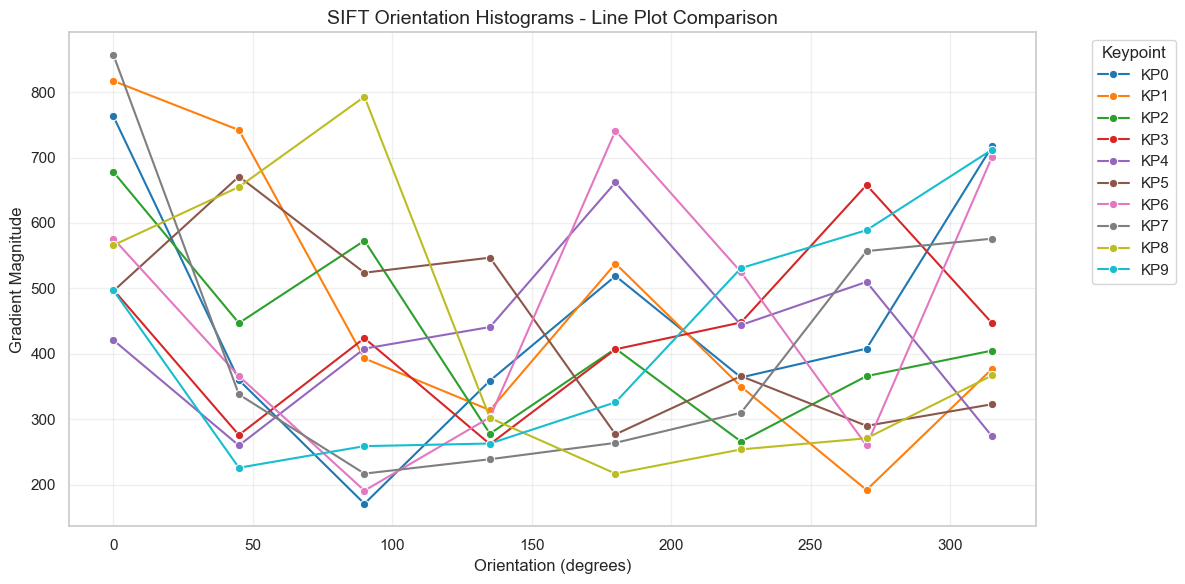

In [108]:
# Analyze and plot SIFT orientation histograms for the first 10 keypoints
n_keypoints = 10
orientation_histograms = (
    descriptors_left[:n_keypoints].reshape(n_keypoints, 16, 8).sum(axis=1)
)

# Create long-form DataFrame
df_long = (
    pd.DataFrame(
        orientation_histograms.T,
        index=np.arange(0, 360, 45),
        columns=[f"KP{i}" for i in range(n_keypoints)],
    )
    .reset_index()
    .melt(id_vars="index", var_name="Keypoint", value_name="Magnitude")
)
df_long.rename(columns={"index": "Orientation"}, inplace=True)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_long,
    x="Orientation",
    y="Magnitude",
    hue="Keypoint",
    marker="o",
    palette="tab10",
)
plt.xlabel("Orientation (degrees)", fontsize=12)
plt.ylabel("Gradient Magnitude", fontsize=12)
plt.title("SIFT Orientation Histograms - Line Plot Comparison", fontsize=14)
plt.legend(title="Keypoint", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Match Features Between Images

Find correspondences between the features detected in both images. We'll use OpenCV's `BFMatcher` (Brute Force Matcher) to match descriptors.

### Key OpenCV Functions:

- **`cv2.BFMatcher(normType, crossCheck)`**: Creates a brute-force matcher
  - `normType`: Distance metric (use `cv2.NORM_L2` for SIFT)
  - `crossCheck=True`: Only return matches where both descriptors are each other's nearest neighbor
  
- **`matcher.match(descriptors1, descriptors2)`**: Finds the best match for each descriptor
  - Returns a list of `DMatch` objects with attributes:
    - `queryIdx`: Index in the first descriptor set
    - `trainIdx`: Index in the second descriptor set
    - `distance`: Distance between descriptors (lower = better match)

- **`cv2.drawMatches(img1, kp1, img2, kp2, matches, output, flags)`**: Visualizes matches
  - Draws lines connecting matched keypoints between two images

In [109]:
# Create a BFMatcher with L2 norm and cross-checking enabled
bf_matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

# Match descriptors between left and right images
matches = bf_matcher.match(descriptors_left, descriptors_right)

# Sort matches by increasing distance (best matches first)
matches = sorted(matches, key=lambda x: x.distance)

print(f"Number of matches found: {len(matches)}")
print(f"Best match distance: {matches[0].distance:.2f}")
print(f"Worst match distance: {matches[-1].distance:.2f}")


Number of matches found: 81
Best match distance: 41.30
Worst match distance: 365.91


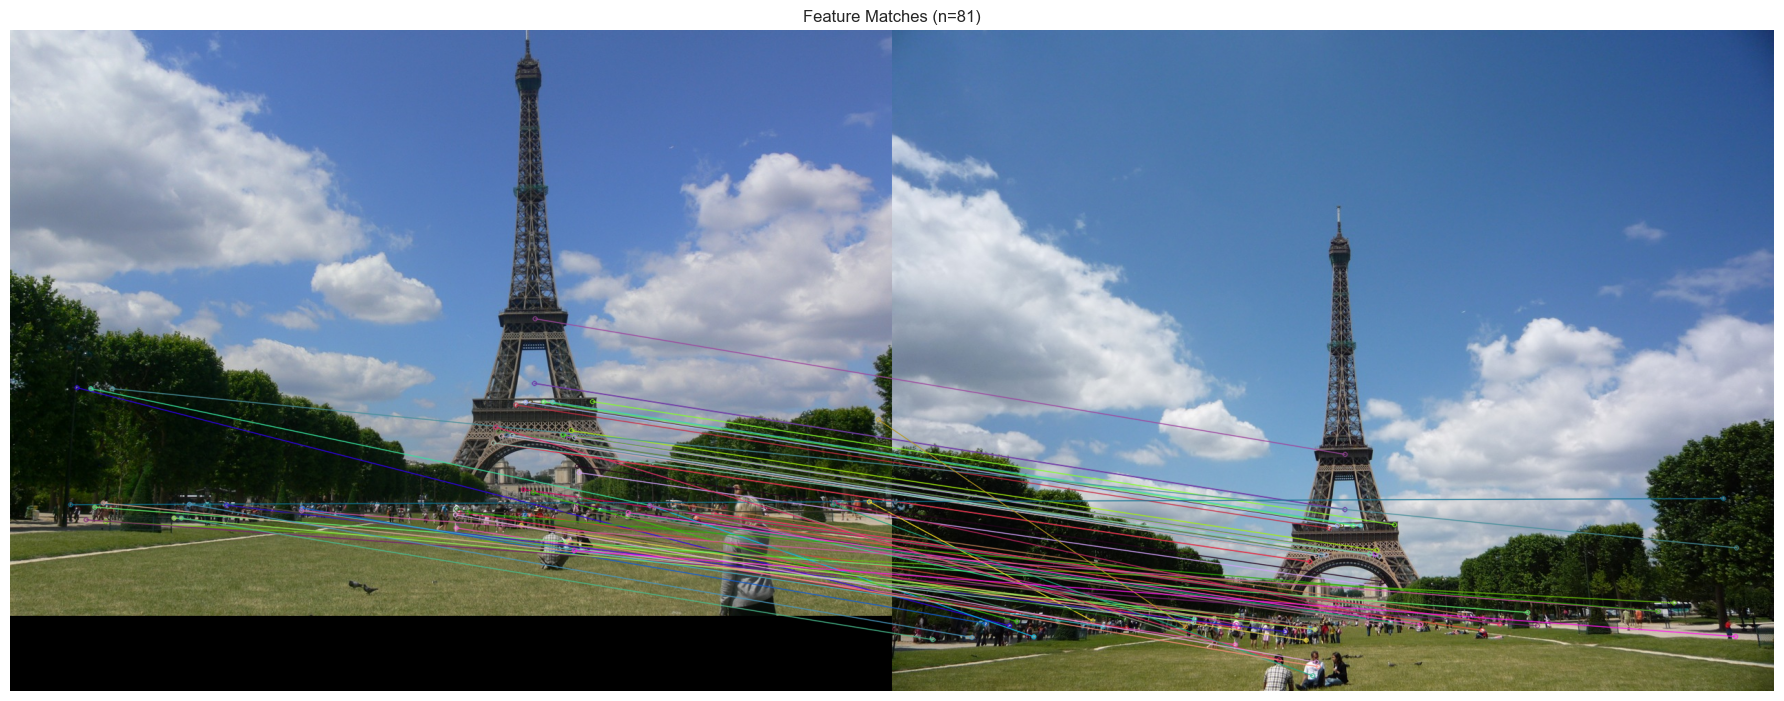

In [110]:
# Visualize all matches
img_matches = cv2.drawMatches(
    left_color,
    keypoints_left,
    right_color,
    keypoints_right,
    matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)

plt.figure(figsize=(18, 8))
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title(f"Feature Matches (n={len(matches)})")
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
from dataclasses import dataclass, field
from typing import Optional, List, Tuple, Dict

from pytransform3d.transform_manager import TransformManager
import pytransform3d.camera as pc
import pytransform3d.transformations as pt
import pytransform3d.rotations as pr
import pytransform3d.plot_utils as ppu


@dataclass
class View:
    """Represents a camera view with its intrinsics, pose, and features.

    Attributes:
        view_id: Unique identifier for this view
        frame_name: Name of the coordinate frame (for TransformManager)
        K: 3x3 camera intrinsic matrix
        image: Optional image data (H x W x 3)
        keypoints: List of cv2.KeyPoint objects
        descriptors: Feature descriptors (N x descriptor_dim)
        width: Image width in pixels
        height: Image height in pixels
    """

    view_id: int
    frame_name: str
    K: np.ndarray  # 3x3 intrinsic matrix
    image: Optional[np.ndarray] = None
    keypoints: List = field(default_factory=list)
    descriptors: Optional[np.ndarray] = None
    width: int = 0
    height: int = 0

    @property
    def focal_length(self) -> float:
        """Return focal length (assumes fx = fy)"""
        ...

    @property
    def principal_point(self) -> Tuple[float, float]:
        """Return principal point (cx, cy)"""
        ...

    @property
    def num_features(self) -> int:
        """Return number of detected features"""
        ...


class ViewManager:
    """Manages multiple camera views and 3D points using pytransform3d.

    Similar to MATLAB's viewSet, this class handles:
    - Camera poses via TransformManager
    - Feature correspondences between views
    - 3D point cloud with visibility information
    """

    def __init__(self, world_frame: str = "world"):
        """Initialize ViewManager with a world coordinate frame.

        Args:
            world_frame: Name of the world coordinate frame (default: "world")
        """
        ...

    def add_view(
        self,
        view_id: int,
        K: np.ndarray,
        R: Optional[np.ndarray] = None,
        t: Optional[np.ndarray] = None,
        image: Optional[np.ndarray] = None,
        keypoints: Optional[List] = None,
        descriptors: Optional[np.ndarray] = None,
    ) -> "ViewManager":
        """Add a camera view with its pose and intrinsics.

        Args:
            view_id: Unique identifier for this view
            K: 3x3 camera intrinsic matrix
            R: 3x3 rotation matrix (world-to-camera), default: identity
            t: 3x1 translation vector (world-to-camera), default: zero
            image: Optional image data (H x W x 3)
            keypoints: Optional list of cv2.KeyPoint objects
            descriptors: Optional feature descriptors (N x descriptor_dim)

        Returns:
            self (for method chaining)
        """
        ...

    def add_connection(
        self, from_view_id: int, to_view_id: int, num_matches: int
    ) -> "ViewManager":
        """Add a connection between two views (feature correspondences).

        Args:
            from_view_id: Source view ID
            to_view_id: Target view ID
            num_matches: Number of matched features

        Returns:
            self (for method chaining)
        """
        ...

    def add_points(
        self,
        points_3d: np.ndarray,
        colors: Optional[np.ndarray] = None,
        visibility: Optional[Dict[int, List[int]]] = None,
    ) -> "ViewManager":
        """Add 3D points to the reconstruction.

        Args:
            points_3d: N x 3 array of 3D point coordinates (in world frame)
            colors: Optional N x 3 array of RGB colors (0-255)
            visibility: Optional dict mapping point_idx -> [view_ids]

        Returns:
            self (for method chaining)
        """
        ...

    def get_transform(self, from_frame: str, to_frame: str) -> np.ndarray:
        """Get 4x4 transformation matrix between two frames.

        Args:
            from_frame: Source frame name (e.g., "cam1", "world")
            to_frame: Target frame name

        Returns:
            4x4 transformation matrix
        """
        ...

    def get_view(self, view_id: int) -> View:
        """Get a View object by ID.

        Args:
            view_id: View identifier

        Returns:
            View object
        """
        ...

    def get_camera_pose(self, view_id: int) -> Tuple[np.ndarray, np.ndarray]:
        """Get camera pose (R, t) in world coordinates.

        Args:
            view_id: View identifier

        Returns:
            R: 3x3 rotation matrix (camera-to-world)
            t: 3x1 translation vector (camera position in world)
        """
        ...

    def triangulate_points(
        self, view1_id: int, view2_id: int, points1: np.ndarray, points2: np.ndarray
    ) -> np.ndarray:
        """Triangulate 3D points from corresponding 2D points in two views.

        Args:
            view1_id: First view ID
            view2_id: Second view ID
            points1: N x 2 array of 2D points in first view
            points2: N x 2 array of 2D points in second view

        Returns:
            N x 3 array of 3D points in world coordinates
        """
        ...

    def plot(self, ax=None, point_size=1, camera_scale=1.0, show_frames=True):
        """Plot the reconstruction with cameras and 3D points.

        Args:
            ax: matplotlib 3D axis (creates new if None)
            point_size: Size of 3D point markers
            camera_scale: Scale factor for camera visualization
            show_frames: Whether to show coordinate frames

        Returns:
            ax: matplotlib 3D axis
        """
        ...

    def __repr__(self) -> str:
        """String representation of the ViewManager."""
        ...


### Example: Using the ViewManager

Now let's demonstrate how to use the `ViewManager` class with our stereo reconstruction. The ViewManager provides a clean interface similar to MATLAB's `viewSet` but with the power of `pytransform3d` for coordinate transformations.

In [ ]:
# Camera parameters
f = 0.08 * 2000  # focal length in pixels
B = 0.4 * 2000  # baseline in pixels

# Image dimensions (get from left image)
height, width = left_gray.shape
cx = width / 2.0  # principal point x
cy = height / 2.0  # principal point y

K = np.array([[f, 0, cx], [0, f, cy], [0, 0, 1]])


In [ ]:
# Create a ViewManager instance
vm = ViewManager(world_frame="world")

# Add left camera (View 1) at the origin with identity pose
vm.add_view(
    view_id=1,
    K=K,
    R=np.eye(3),  # Identity rotation
    t=np.zeros(3),  # At origin
    image=left_color,
    keypoints=keypoints_left,
    descriptors=descriptors_left,
)

# Add right camera (View 2) translated along X-axis by baseline
vm.add_view(
    view_id=2,
    K=K,
    R=np.eye(3),  # Same orientation as left camera (rectified stereo)
    t=np.array([B, 0, 0]),  # Shifted by baseline distance
    image=right_color,
    keypoints=keypoints_right,
    descriptors=descriptors_right,
)

# Add connection between the two views
vm.add_connection(from_view_id=1, to_view_id=2, num_matches=len(matches))

print(vm)
print(f"\nView 1 frame: {vm.get_view(1).frame_name}")
print(f"View 2 frame: {vm.get_view(2).frame_name}")
print(f"View 1 focal length: {vm.get_view(1).focal_length:.2f} px")
print(f"View 1 principal point: {vm.get_view(1).principal_point}")


In [ ]:
# Use ViewManager's built-in triangulation method
# Extract matched points (same as before)
points_left = np.array([keypoints_left[m.queryIdx].pt for m in matches])
points_right = np.array([keypoints_right[m.trainIdx].pt for m in matches])

# Triangulate using the ViewManager
points_3d_vm = vm.triangulate_points(
    view1_id=1, view2_id=2, points1=points_left, points2=points_right
)

print(f"Triangulated {len(points_3d_vm)} 3D points")
print(f"Point cloud shape: {points_3d_vm.shape}")
print(f"\nPoint cloud statistics:")
print(f"X range: [{points_3d_vm[:, 0].min():.2f}, {points_3d_vm[:, 0].max():.2f}]")
print(f"Y range: [{points_3d_vm[:, 1].min():.2f}, {points_3d_vm[:, 1].max():.2f}]")
print(f"Z range: [{points_3d_vm[:, 2].min():.2f}, {points_3d_vm[:, 2].max():.2f}]")


In [ ]:
# Add the 3D points to the ViewManager
vm.add_points(points_3d_vm)

# Query camera poses
R1, t1 = vm.get_camera_pose(view_id=1)
R2, t2 = vm.get_camera_pose(view_id=2)

print("Camera 1 position (world frame):", t1)
print("Camera 2 position (world frame):", t2)
print(f"Baseline distance: {np.linalg.norm(t2 - t1):.2f} pixels")

# Query transformation between camera frames
T_cam1_to_cam2 = vm.get_transform("cam1", "cam2")
print(f"\nTransformation from cam1 to cam2:")
print(T_cam1_to_cam2)


In [ ]:
# Visualize using the ViewManager's built-in plot method
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")

vm.plot(ax=ax, point_size=20, camera_scale=1.0, show_frames=True)

ax.set_title("Sparse 3D Reconstruction using ViewManager", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# TODO: Compute 3D coordinates for all valid matched points
# Use the formulas:
# Z = (f * B) / disparity
# X = (u - cx) * Z / f
# Y = (v - cy) * Z / f

# Depth (Z coordinate)
Z = None

# X coordinate
X = None

# Y coordinate
Y = None

# Combine into a single array of 3D points (N x 3)
# points_3d = np.column_stack((X, Y, Z))


# Outliers: 42


## 6. Create a View Set for Visualization

We'll create a simple class to manage camera views and connections, similar to MATLAB's `vSet` class. This will help us organize the camera poses and visualize the reconstruction.

### View Set Components:

A view set typically stores:
- **Views**: Camera poses (rotation and translation relative to a world frame)
- **Connections**: Relationships between views (matched features)
- **Points**: 3D points visible in multiple views

For our stereo case:
- View 1 (left camera): Identity pose at origin
- View 2 (right camera): Translated along X-axis by baseline distance


## 7. Visualize the Reconstruction with Camera Poses